In [1]:
import os
import math
import wandb
import random
import time
import logging
import inspect
import argparse
import datetime
import numpy as np

from pathlib import Path
from tqdm.auto import tqdm
from einops import rearrange, repeat
from omegaconf import OmegaConf
from typing import Dict, Optional, Tuple

import torch
import torch.nn.functional as F
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader

import diffusers
from diffusers import AutoencoderKL, DDIMScheduler
from diffusers.optimization import get_scheduler
from diffusers.utils import check_min_version
from diffusers.utils.import_utils import is_xformers_available
from diffusers.training_utils import EMAModel

import transformers
from transformers import CLIPTextModel, CLIPTokenizer

from accelerate import Accelerator, DistributedDataParallelKwargs, InitProcessGroupKwargs
from accelerate.logging import get_logger
from accelerate.utils import set_seed

from swomo.data.dataset import SurgicalDataset
from swomo.models.videoldm_unet import VideoLDMUNet3DConditionModel
from swomo.models.videoldm_controlnet import ControlNetModel
from swomo.graph_encoder.graph_segclip_masked import GraphEncoder
from swomo.pipelines.pipeline_conditional_animation import ConditionalAnimationPipeline
from swomo.pipelines.pipeline_controlnet_animation import ControlNetAnimationPipeline
from swomo.utils.util import save_videos_grid, save_videos_grid_from_paths
from swomo.utils.get_scene_graph import GraphConstructor


import pandas as pd

import matplotlib.pyplot as plt
from PIL import Image
import cv2


/home/MichalMo/anaconda3/envs/swomo/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.0'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# parser = argparse.ArgumentParser()
# parser.add_argument("--config",   type=str, required=True)
# parser.add_argument("--name", "-n", type=str, default="")
# parser.add_argument("--wandb",    action="store_true")
# parser.add_argument("optional_args", nargs='*', default=[])
# args = parser.parse_args()

# name   = args.name + "_" + Path(args.config).stem



config = OmegaConf.load("configs/training/training_img_graph_vid_cataracts_test.yaml")

print(config.train_data)
train_dataset = SurgicalDataset(**config.train_data, train_graph_encoder = True)


{'dataset': 'surgical', 'dataset_name': 'cataract', 'video_folder': ['/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K'], 'class_size': 14, 'split_mode': 'train', 'return_graph_emb': False, 'return_cond_videos': True, 'sample_size': 256, 'sample_n_frames': 21, 'apply_augmentation': False, 'overlap_size': 100, 'frame_stride': 1, 'embedding_type': 'combined', 'model_masked': './checkpoints/Cataract-1K/graphencoder_masked/best_val_loss.pth', 'model_segclip': './checkpoints/Cataract-1K/graphencoder_segclip/best_val_loss.pth', 'graph_input_dim': 20, 'graph_hidden_dim': 256, 'graph_embedding_dim': 256, 'trainable': False, 'graph_conv_type': 'GATv2Conv', 'graph_norm_type': 'LayerNorm'}


In [3]:
train_dataset.train_graph_encoder

True

In [4]:

config = OmegaConf.load("configs/training/training_img_graph_xvid_cataracts.yaml")

print(config.train_data)
train_dataset_xvid = SurgicalDataset(**config.train_data)

{'dataset': 'surgical', 'dataset_name': 'cataract', 'video_folder': ['datasets/Cataract-1K'], 'class_size': 14, 'split_mode': 'train', 'return_graph_emb': True, 'return_cond_videos': False, 'sample_size': 128, 'sample_n_frames': 16, 'apply_augmentation': False, 'embedding_type': 'combined', 'model_masked': './checkpoints/Cataract-1K/graphencoder_masked/best_val_loss.pth', 'model_segclip': './checkpoints/Cataract-1K/graphencoder_segclip/best_val_loss.pth', 'graph_input_dim': 20, 'graph_hidden_dim': 256, 'graph_embedding_dim': 256, 'trainable': False, 'graph_conv_type': 'GATv2Conv', 'graph_norm_type': 'LayerNorm'}


In [5]:
train_dataset_xvid.train_graph_encoder

False

In [6]:
print(len(train_dataset))
print(train_dataset.sample[0])

train_dataloader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=4,
    num_workers=1,
    pin_memory=True,
)

# print(len(train_dataset))
# print(train_dataset.sample[0])

train_dataloader_xvid = DataLoader(
    train_dataset_xvid,
    shuffle=True,
    batch_size=4,
    num_workers=1,
    pin_memory=True,
)

21
{'video': 'case_2000', 'video_folder': '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K', 'frame': ['0000000000.jpg', '0000000001.jpg', '0000000002.jpg', '0000000003.jpg', '0000000004.jpg', '0000000005.jpg', '0000000006.jpg', '0000000007.jpg', '0000000008.jpg', '0000000009.jpg', '0000000010.jpg', '0000000011.jpg', '0000000012.jpg', '0000000013.jpg', '0000000014.jpg', '0000000015.jpg', '0000000016.jpg', '0000000017.jpg', '0000000018.jpg', '0000000019.jpg', '0000000020.jpg', '0000000021.jpg'], 'segm': ['/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_sim/case_2000/0000000000.png', '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_sim/case_2000/0000000001.png', '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_sim/case_2000/0000000002.png', '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_sim/case_2000/0000000003.png', '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_sim/case_2000/000000

In [7]:
train_dataset.sample[0]

{'video': 'case_2000',
 'video_folder': '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K',
 'frame': ['0000000000.jpg',
  '0000000001.jpg',
  '0000000002.jpg',
  '0000000003.jpg',
  '0000000004.jpg',
  '0000000005.jpg',
  '0000000006.jpg',
  '0000000007.jpg',
  '0000000008.jpg',
  '0000000009.jpg',
  '0000000010.jpg',
  '0000000011.jpg',
  '0000000012.jpg',
  '0000000013.jpg',
  '0000000014.jpg',
  '0000000015.jpg',
  '0000000016.jpg',
  '0000000017.jpg',
  '0000000018.jpg',
  '0000000019.jpg',
  '0000000020.jpg',
  '0000000021.jpg'],
 'segm': ['/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_sim/case_2000/0000000000.png',
  '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_sim/case_2000/0000000001.png',
  '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_sim/case_2000/0000000002.png',
  '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_sim/case_2000/0000000003.png',
  '/home/MichalMo/projects/SurgSora/SWo

dict_keys(['graph', 'image', 'class_label', 'segmentation', 'all_frame_path', 'first_frame_path', 'text'])
torch.Size([21, 256, 256, 3])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([21, 256, 256, 14]) (array([0., 1.], dtype=float32), array([17891328,  1376256]))
torch.Size([4, 14]) tensor([[1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]])
dict_keys(['graph', 'image', 'class_label', 'segmentation', 'all_frame_path', 'first_frame_path', 'text'])
torch.Size([21, 256, 256, 3])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([21, 256, 256, 14]) (array([0., 1.], dtype=float32), array([17891328,  1376256]))
torch.Size([4, 14]) tensor([[1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0]])


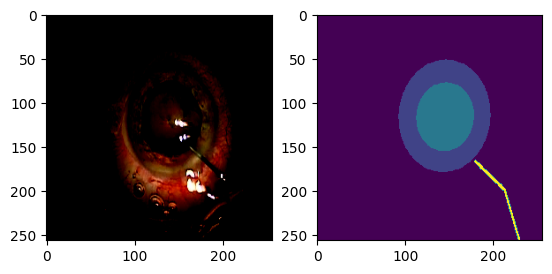

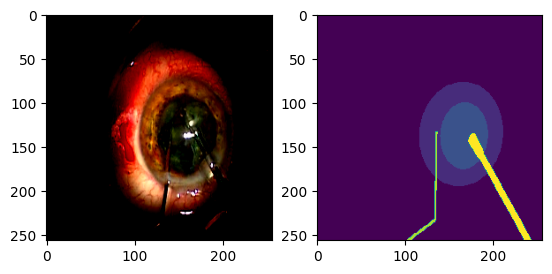

In [8]:
for step, batch in enumerate(train_dataloader):

    print(batch.keys())


    pixel_values = batch["image"]
    pixel_values = rearrange(pixel_values, "b f c h w -> b f h w c")[0]

    print(pixel_values.shape)


    mask = batch["segmentation"]
    mask = rearrange(mask, "b f c h w -> b f h w c")[0]
    masks_label_map = np.argmax(mask, axis=-1)#.astype(np.float32)

    print(mask.shape, np.unique(mask, return_counts=1))

    print(batch["class_label"].shape, batch["class_label"])

    plt.figure()
    plt.subplot(121)

    plt.imshow(np.array(pixel_values[0]).astype(np.float32))


    plt.subplot(122)
    plt.imshow(masks_label_map[0])




    if step ==1:
        break

In [9]:
for step, batch in enumerate(train_dataloader_xvid):

    print(batch.keys())


    pixel_values = batch["pixel_values"]
    pixel_values = rearrange(pixel_values, "b f c h w -> b f h w c")[0]

    print(pixel_values.shape)


    mask = batch["segm"]
    print(mask.shape, np.unique(mask, return_counts=1))


    if step ==1:
        break

dict_keys(['graph', 'pixel_values', 'cond_video_values', 'text', 'first_frame_path', 'all_frame_path', 'cond_video_path'])
torch.Size([16, 128, 128, 3])


KeyError: 'segm'

In [107]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

def analyze_masks(base_folder, save_folder_path):
    base_dir = Path(base_folder)
    all_cases_data = []

    # Common image extensions (adjust if your masks use a different format)
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}

    # 1) Iterate over subfolders
    for i,case_folder in enumerate(sorted(base_dir.glob("case_*"))):
        if not case_folder.is_dir():
            continue
            

        if i == 1:
            break


        case_name = case_folder.name
        case_full_data = []

        # Gather all image paths in the current subfolder
        image_paths = [
            p for p in case_folder.iterdir() 
            if p.is_file() and p.suffix.lower() in valid_extensions
        ]
        
        num_images = len(image_paths)
        if num_images == 0:
            print(f"Warning: No images found in {case_name}. Skipping.")
            continue

        case_class_counts = {}
        total_pixels = 0

        # Iterate over images in the subfolder
        for img_path in sorted(image_paths):
            # Read image unchanged to preserve exact mask/pixel values
            img = np.array(Image.open(img_path))
            
            if img is None:
                print(f"Warning: Could not read {img_path}")
                continue



            # Calculate unique classes and their pixel counts in this image
            unique_classes, counts = np.unique(img, return_counts=True)
            # print("unique_classes ", unique_classes)

            # Accumulate counts for the whole case
            for cls, count in zip(unique_classes, counts):
                case_class_counts[cls] = case_class_counts.get(cls, 0) + count
                total_pixels += count

            
            # print(img_path)

            img_name = str(img_path).split("/")[-1]

            case_data = {
                "case_name": case_name,
                "img_name": img_name,
                "number_of_unique_classes": len(case_class_counts)
            }

            # Calculate percentage surface for each unique class
            for cls, count in case_class_counts.items():
                percentage = (count / total_pixels) * 100
                case_data[f"class_{cls}_pct"] = np.round(percentage,3)

            all_cases_data.append(case_data)
            case_full_data.append(case_data)

        # Compile the final pandas DataFrame
        df_case = pd.DataFrame(case_full_data)
        
        print(case_name)
        save_folder_path2 = os.path.join(save_folder_path, f"{case_name}_info.csv")
        df_case.to_csv(save_folder_path2, index = False)




    # Compile the final pandas DataFrame
    df = pd.DataFrame(all_cases_data)
    
    # Sort by case name for better readability
    df.sort_values(by="case_name", inplace=True)
    df.reset_index(drop=True, inplace=True)
    

    

    return df

# --- Execution ---
if __name__ == "__main__":
    folder_path = "datasets/Cataract-1K/masks_real"
    

    save_folder_path = "datasets/Cataract-1K/dataset_info/masks_real_info"

    # Check if directory exists before running
    if not os.path.exists(folder_path):
        print(f"Error: The directory '{folder_path}' does not exist.")
    else:
        results_df = analyze_masks(folder_path, save_folder_path)
        
        # Display the first few rows
        print(results_df.head())
        
        # Optional: Save to CSV

        # results_df.to_csv("mask_analysis_results.csv", index=False)

case_2000
   case_name        img_name  number_of_unique_classes  class_0_pct  \
0  case_2000  0000000000.png                         3       84.404   
1  case_2000  0000001373.png                        10       84.171   
2  case_2000  0000001372.png                        10       84.170   
3  case_2000  0000001371.png                        10       84.170   
4  case_2000  0000001370.png                        10       84.170   

   class_1_pct  class_2_pct  class_12_pct  class_4_pct  class_11_pct  \
0        8.947        6.649           NaN          NaN           NaN   
1        8.105        6.427         0.277        0.027         0.084   
2        8.106        6.427         0.277        0.027         0.085   
3        8.107        6.427         0.277        0.027         0.085   
4        8.107        6.427         0.278        0.027         0.085   

   class_5_pct  class_13_pct  class_8_pct  class_7_pct  
0          NaN           NaN          NaN          NaN  
1        0.119  

In [12]:
import os
len(os.listdir("datasets/Cataract-1K/dataset_info/masks_real_info"))

869

In [108]:
results_df.sort_values(["case_name", "img_name"]).head()

,case_name,img_name,number_of_unique_classes,class_0_pct,class_1_pct,class_2_pct,class_12_pct,class_4_pct,class_11_pct,class_5_pct,class_13_pct,class_8_pct,class_7_pct
0,case_2000,0000000000.png,3,84.404,8.947,6.649,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1372,case_2000,0000000001.png,3,84.331,9.006,6.663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1371,case_2000,0000000002.png,3,84.356,8.977,6.668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1370,case_2000,0000000003.png,3,84.371,8.965,6.663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1369,case_2000,0000000004.png,3,84.384,8.964,6.652,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1]:
results_df.shape

NameError: name 'results_df' is not defined

In [12]:
results_df.iloc[:,2:].mean()

number_of_unique_classes     8.453699
class_0_pct                 85.327449
class_1_pct                  5.977123
class_2_pct                  7.577256
class_4_pct                  0.082016
class_12_pct                 0.252428
class_11_pct                 0.142384
class_5_pct                  0.150598
class_6_pct                  0.236544
class_8_pct                  0.422614
class_7_pct                  0.275527
class_13_pct                 0.492854
dtype: float64

In [13]:
folder_path

'datasets/Cataract-1K/masks_real'

In [109]:
def analyse_dataset_info(main_path):


    files_paths = [
    str(p) for p in Path(main_path).iterdir() 
    if p.is_file() and p.suffix.lower() 
]
    
    print(files_paths)


    full_data = []

    for file_path in files_paths:

        df = pd.read_csv(file_path)
        # print(df.shape)

        d = results_df.iloc[:,2:].mean()
        # print(d)


        case_data = { "case ": file_path.split("/")[-1].split(".")[0][:-5],
                     **d
    }
        
        
        full_data.append(case_data)

    
    df = pd.DataFrame(full_data)

    print(df.shape)
    return df

main_path = "datasets/Cataract-1K/dataset_info/masks_real_info"
df = analyse_dataset_info(main_path)

# df.to_csv(os.path.join(main_path, "dataset_info.csv"))

['datasets/Cataract-1K/dataset_info/masks_real_info/case_2421_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_2485_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_2166_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_2398_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_2407_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_2021_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_2320_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_2687_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_2143_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_4927_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_2561_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_5058_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_5057_info.csv', 'datasets/Cataract-1K/dataset_info/masks_real_info/case_2757_in

In [110]:
df.head

<bound method NDFrame.head of          case   number_of_unique_classes  class_0_pct  class_1_pct  \
0    case_2421                  8.482422    83.890873     8.225287   
1    case_2485                  8.482422    83.890873     8.225287   
2    case_2166                  8.482422    83.890873     8.225287   
3    case_2398                  8.482422    83.890873     8.225287   
4    case_2407                  8.482422    83.890873     8.225287   
..         ...                       ...          ...          ...   
864  case_2457                  8.482422    83.890873     8.225287   
865  case_8039                  8.482422    83.890873     8.225287   
866  case_2342                  8.482422    83.890873     8.225287   
867  case_2236                  8.482422    83.890873     8.225287   
868  case_2003                  8.482422    83.890873     8.225287   

     class_2_pct  class_12_pct  class_4_pct  class_11_pct  class_5_pct  \
0       6.445689      0.579319     0.055642      0.0954

In [111]:
import pandas as pd
import numpy as np

def generate_summaries(df):
    # 1. Clean Data: Fill NaNs with 0 for easier math
    df = df.fillna(0)
    
    # Identify all class percentage columns
    class_cols = [col for col in df.columns if col.startswith('class_') and col.endswith('_pct')]
    
    # --- PER-IMAGE SUMMARY ---
    def get_active_classes(row):
        # Extracts class number (e.g., '0' from 'class_0_pct') if percentage > 0
        return [int(c.split('_')[1]) for c in class_cols if row[c] > 0]

    # List of classes > 0
    df['active_classes'] = df.apply(get_active_classes, axis=1)
    
    # Sum of classes (Total percentage representation on the image)
    df['sum_percentages'] = df[class_cols].sum(axis=1)
    
    image_summary_df = df[['case_name', 'img_name', 'active_classes', 'sum_percentages']].copy()
    
    # --- PER-CASE SUMMARY ---
    def aggregate_case(group):
        # Find all unique classes across all frames in this case
        all_classes_in_case = set(x for lst in group['active_classes'] for x in lst)
        
        # Calculate the mean percentage representation of each class across the entire case
        mean_pcts = {f"avg_{c}": group[c].mean() for c in class_cols}
        
        return pd.Series({
            'total_frames': len(group),
            'total_unique_classes': len(all_classes_in_case),
            'unique_classes_list': list(all_classes_in_case),
            **mean_pcts
        })

    case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()
    
    return df, image_summary_df, case_summary_df

# Example Usage:
df, img_summary, case_summary = generate_summaries(results_df)

/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()


In [112]:
df.head(10)

,case_name,img_name,number_of_unique_classes,class_0_pct,class_1_pct,class_2_pct,class_12_pct,class_4_pct,class_11_pct,class_5_pct,class_13_pct,class_8_pct,class_7_pct,active_classes,sum_percentages
0,case_2000,0000000000.png,3,84.404,8.947,6.649,0.000,0.000,0.000,0.000,0.000,0.000,0.000,"[0, 1, 2]",100.000
1,case_2000,0000001373.png,10,84.171,8.105,6.427,0.277,0.027,0.084,0.119,0.324,0.325,0.141,"[0, 1, 2, 12, 4, 11, 5, 13, 8, 7]",100.000
2,case_2000,0000001372.png,10,84.170,8.106,6.427,0.277,0.027,0.085,0.120,0.324,0.324,0.140,"[0, 1, 2, 12, 4, 11, 5, 13, 8, 7]",100.000
3,case_2000,0000001371.png,10,84.170,8.107,6.427,0.277,0.027,0.085,0.120,0.324,0.323,0.140,"[0, 1, 2, 12, 4, 11, 5, 13, 8, 7]",100.000
4,case_2000,0000001370.png,10,84.170,8.107,6.427,0.278,0.027,0.085,0.120,0.324,0.322,0.139,"[0, 1, 2, 12, 4, 11, 5, 13, 8, 7]",99.999
5,case_2000,0000001369.png,10,84.169,8.108,6.428,0.278,0.028,0.085,0.120,0.324,0.322,0.139,"[0, 1, 2, 12, 4, 11, 5, 13, 8, 7]",100.001
6,case_2000,0000001368.png,10,84.169,8.108,6.428,0.278,0.028,0.085,0.120,0.325,0.321,0.139,"[0, 1, 2, 12, 4, 11, 5, 13, 8, 7]",100.001
7,case_2000,0000001367.png,10,84.169,8.109,6.428,0.278,0.028,0.085,0.120,0.325,0.320,0.138,"[0, 1, 2, 12, 4, 11, 5, 13, 8, 7]",100.000
8,case_2000,0000001366.png,10,84.169,8.110,6.429,0.278,0.028,0.085,0.120,0.325,0.319,0.138,"[0, 1, 2, 12, 4, 11, 5, 13, 8, 7]",100.001
9,case_2000,0000001365.png,10,84.169,8.110,6.429,0.279,0.028,0.085,0.120,0.325,0.319,0.137,"[0, 1, 2, 12, 4, 11, 5, 13, 8, 7]",100.001


In [113]:
img_summary.sort_values(["case_name", "img_name"]).head()

,case_name,img_name,active_classes,sum_percentages
0,case_2000,0000000000.png,"[0, 1, 2]",100.000
1372,case_2000,0000000001.png,"[0, 1, 2]",100.000
1371,case_2000,0000000002.png,"[0, 1, 2]",100.001
1370,case_2000,0000000003.png,"[0, 1, 2]",99.999
1369,case_2000,0000000004.png,"[0, 1, 2]",100.000


In [18]:
case_summary.head()

,case_name,total_frames,total_unique_classes,unique_classes_list,avg_class_0_pct,avg_class_1_pct,avg_class_2_pct,avg_class_4_pct,avg_class_12_pct,avg_class_11_pct,avg_class_5_pct,avg_class_6_pct,avg_class_8_pct,avg_class_7_pct,avg_class_13_pct
0,case_2043,1032,11,"[0, 1, 2, 4, 5, 6, 7, 8, 11, 12, 13]",84.565448,4.539238,9.754835,0.077328,0.218553,0.163222,0.128121,0.102872,0.035351,0.018308,0.396748
1,case_2079,1848,10,"[0, 1, 2, 4, 5, 6, 7, 8, 11, 12]",84.076072,6.390253,8.150730,0.052893,0.561831,0.169414,0.087951,0.165128,0.261363,0.084359,0.000000
2,case_2235,1512,10,"[0, 1, 2, 4, 5, 6, 7, 8, 11, 12]",85.319972,6.551991,6.968095,0.106596,0.207261,0.105995,0.139167,0.225271,0.204113,0.171503,0.000000
3,case_2286,1040,10,"[0, 1, 2, 4, 5, 6, 7, 8, 11, 12]",85.016591,5.013195,9.044214,0.112056,0.077145,0.068300,0.139999,0.218689,0.196822,0.112987,0.000000
4,case_2454,1456,9,"[0, 1, 2, 4, 5, 7, 8, 11, 13]",84.343310,8.664900,5.648758,0.076999,0.000000,0.181402,0.156786,0.000000,0.344560,0.232175,0.351104


In [146]:
import pandas as pd

import pandas as pd

def find_continuous_batches(df, exact_frames, exact_classes):
    """
    Finds continuous batches of frames containing EXACTLY the specified classes
    and subdivides them into chunks of exactly `exact_frames`.
    """
    allowed_set = set(exact_classes)
    
    # Extract integer frame number
    df['frame_index'] = df['img_name'].str.extract(r'(\d+)').astype(int)
    
    # Sort strictly by case and frame order
    df = df.sort_values(['case_name', 'frame_index']).reset_index(drop=True)
    
    # STRICT CHECK: The active classes must exactly match the requested classes
    df['is_valid'] = df['active_classes'].apply(lambda x: set(x) == allowed_set)
    
    # Filter to only valid frames
    valid_df = df[df['is_valid']].copy()
    
    if valid_df.empty:
        return pd.DataFrame(), pd.DataFrame()
    
    # 1. Identify continuous blocks (a jump in frame_index starts a new block)
    valid_df['block_id'] = ((valid_df['case_name'] != valid_df['case_name'].shift()) | 
                            (valid_df['frame_index'].diff() != 1)).cumsum()
    
    # 2. Subdivide blocks into chunks of size `exact_frames`
    # Count the row number within the continuous block (0, 1, 2, 3...)
    valid_df['row_in_block'] = valid_df.groupby('block_id').cumcount()
    
    # Assign a chunk index (e.g., rows 0-4 get 0, rows 5-9 get 1)
    valid_df['chunk_idx'] = valid_df['row_in_block'] // exact_frames
    
    # Create a unique batch ID combining the block and the chunk
    valid_df['batch_id'] = valid_df['block_id'].astype(str) + "_" + valid_df['chunk_idx'].astype(str)
    
    # 3. Filter out incomplete chunks (e.g., the last 2 frames of a 12-frame block)
    batch_sizes = valid_df.groupby('batch_id').size()
    complete_batches = batch_sizes[batch_sizes == exact_frames].index
    
    filtered_batches_df = valid_df[valid_df['batch_id'].isin(complete_batches)].copy()
    
    # 4. Create summary dataframe
    batch_summary = filtered_batches_df.groupby(['case_name', 'batch_id']).agg({
        'img_name': ['first', 'last', 'count']
    }).reset_index()
    
    batch_summary.columns = ['case_name', 'batch_id', 'start_frame', 'end_frame', 'frame_count']
    
    return filtered_batches_df, batch_summary

df_case = pd.read_csv("datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv")
df, img_summary, case_summary = generate_summaries(df_case)


batch_df, batch_summary = find_continuous_batches(df, exact_frames=21, exact_classes=[0, 1, 2])

/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()


In [147]:
df.shape

(2048, 16)

In [148]:
batch_df

,case_name,img_name,number_of_unique_classes,class_0_pct,class_1_pct,class_2_pct,class_12_pct,class_4_pct,class_11_pct,class_5_pct,...,class_8_pct,class_7_pct,active_classes,sum_percentages,frame_index,is_valid,block_id,row_in_block,chunk_idx,batch_id
0,case_2000,0000000000.png,3,84.404,8.947,6.649,0.0,0.0,0.0,0.0,...,0.0,0.0,"[0, 1, 2]",100.000,0,True,1,0,0,1_0
1,case_2000,0000000001.png,3,84.331,9.006,6.663,0.0,0.0,0.0,0.0,...,0.0,0.0,"[0, 1, 2]",100.000,1,True,1,1,0,1_0
2,case_2000,0000000002.png,3,84.356,8.977,6.668,0.0,0.0,0.0,0.0,...,0.0,0.0,"[0, 1, 2]",100.001,2,True,1,2,0,1_0
3,case_2000,0000000003.png,3,84.371,8.965,6.663,0.0,0.0,0.0,0.0,...,0.0,0.0,"[0, 1, 2]",99.999,3,True,1,3,0,1_0
4,case_2000,0000000004.png,3,84.384,8.964,6.652,0.0,0.0,0.0,0.0,...,0.0,0.0,"[0, 1, 2]",100.000,4,True,1,4,0,1_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,case_2000,0000000058.png,3,85.031,8.541,6.428,0.0,0.0,0.0,0.0,...,0.0,0.0,"[0, 1, 2]",100.000,58,True,1,58,2,1_2
59,case_2000,0000000059.png,3,85.034,8.539,6.427,0.0,0.0,0.0,0.0,...,0.0,0.0,"[0, 1, 2]",100.000,59,True,1,59,2,1_2
60,case_2000,0000000060.png,3,85.036,8.538,6.426,0.0,0.0,0.0,0.0,...,0.0,0.0,"[0, 1, 2]",100.000,60,True,1,60,2,1_2
61,case_2000,0000000061.png,3,85.036,8.539,6.425,0.0,0.0,0.0,0.0,...,0.0,0.0,"[0, 1, 2]",100.000,61,True,1,61,2,1_2


In [149]:
batch_summary

,case_name,batch_id,start_frame,end_frame,frame_count
0,case_2000,1_0,0000000000.png,0000000020.png,21
1,case_2000,1_1,0000000021.png,0000000041.png,21
2,case_2000,1_2,0000000042.png,0000000062.png,21


In [164]:
df_list = []


    # base_dir = Path(base_folder)
    # all_cases_data = []

    # # Common image extensions (adjust if your masks use a different format)
    # valid_extensions = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}

    # # 1) Iterate over subfolders
    # for i,case_folder in enumerate(sorted(base_dir.glob("case_*"))):

base_dir = Path("datasets/Cataract-1K/dataset_info/masks_real_info")


for i, case_path in enumerate(sorted(base_dir.glob("case_*"))):
    print(case_name)
    if i == 3000000:
        break
    df_case = pd.read_csv(case_path)
    df, img_summary, case_summary = generate_summaries(df_case)


    batch_df, batch_summary = find_continuous_batches(df, exact_frames=21, exact_classes=[0, 1, 2])

    df_list.append(batch_summary)


final_df = pd.concat(df_list)
final_df.shape

datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv


/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()
/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()
/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on th

datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv


/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()
/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()
/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on th

datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv


...

datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv


/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()
/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()
/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on th

datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv
datasets/Cataract-1K/dataset_info/masks_real_info/case_2000_info.csv


/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()
/tmp/ipykernel_2995676/498613443.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_summary_df = df.groupby('case_name').apply(aggregate_case).reset_index()


(564, 5)

In [165]:
final_df.head(15)

,case_name,batch_id,start_frame,end_frame,frame_count
0,case_2000,1_0,0000000000.png,0000000020.png,21
1,case_2000,1_1,0000000021.png,0000000041.png,21
2,case_2000,1_2,0000000042.png,0000000062.png,21
0,case_2004,1_0,0000000000.png,0000000020.png,21
1,case_2004,1_1,0000000021.png,0000000041.png,21
0,case_2005,1_0,0000000000.png,0000000020.png,21
1,case_2005,1_1,0000000021.png,0000000041.png,21
0,case_2009,1_0,0000000000.png,0000000020.png,21
0,case_2011,1_0,0000000000.png,0000000020.png,21
0,case_2015,1_0,0000000000.png,0000000020.png,21


In [176]:
final_df.to_csv("datasets/Cataract-1K/dataset_info/masks_real_info/batches_21_frames_classes_0,1,2.csv")

In [177]:
df = pd.read_csv("datasets/Cataract-1K/dataset_info/masks_real_info/batches_21_frames_classes_0,1,2.csv", index_col=0)

In [253]:

import os
from torch.utils.data import Dataset
import cv2
import PIL
from PIL import Image
import pickle
import numpy as np
import torch
import random
import pandas as pd


class DatasetRetinaVideoBatches(Dataset):
    def __init__(self, image_size = 256, df_path = []):
        self.data = []
        # with open("/home/MichalMo/projects/SurGrID/datasets/Cataract-1K/Cataract_1K_seg_full.json", 'rt') as f:
        #     for line in f:
        #         self.data.append(json.loads(line))



        # self.df = pd.read_csv("/home/MichalMo/projects/SurGrID/datasets/Cataract-1K/GFG_test.csv")
        # print(self.df.columns)
        # print(self.df.head(3))

        self.image_shape = (image_size, image_size)
        self.num_frames = 21

        self.images_folder = '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg'
        self.masks_folder = '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_real'

        self.df = pd.read_csv(df_path, index_col=0)



        # self.image_paths = self.image_paths[:10]
        print(f"Loaded {self.df.shape[0]} samples")


    def __len__(self):
        return len(self.df.shape[0]) 


    def load_image(self, path, img_type):

        if img_type == "image":

            image = Image.open(path)

            image = np.asarray(image)
            image = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)

            image = image.astype(np.float16).transpose(2,0,1)
            # image = image.astype(np.float16)
            # image = image.transpose(2,0,1)
            # image = np.moveaxis(image, -1, 0)
            image = image / 255.


        elif img_type == "mask":


            # mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale


            # mask = np.asarray(mask)
            # mask = cv2.resize(mask, self.image_shape, interpolation=cv2.INTER_NEAREST)


            image = Image.open(path)
            image = np.asarray(image)
            mask = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)


            # segmentation = np.eye(14)[mask].astype(np.float32) #.transpose(2,0,1)

            # segmentation = segmentation.astype(np.float16)


            # # print(image.shape, segmentation.shape)
            # segmentation = segmentation.transpose(2,0,1)

            image = mask

        return image


    def get_batch(self, images_paths, masks_paths):

        # base_idx = idx % len(self.df)
        image_list = []
        mask_list = []


        for path in images_paths:


            image = self.load_image(path, img_type ="image")

            image_list.append(image)


        for path in masks_paths:


            mask = self.load_image(path, img_type = "mask")

            mask_list.append(mask)

        images = np.stack(image_list)
        masks = np.stack(mask_list)

        return images, masks


    def create_paths(self, df_batch):

        image_paths, masks_paths =    [], []

        n1= df_batch.start_frame.split(".")[0]
        # n2= case_video_var.end_frame(".")[0]

        for i in range(self.num_frames):
            print(int(n1)+i)

            img_p = self.images_folder + "/" + df_batch.case_name + f"/{str(int(n1)+i).zfill(10)}" + ".jpg"
            mask_p = self.masks_folder + "/" + df_batch.case_name + f"/{str(int(n1)+i).zfill(10)}" + ".png"
            image_paths.append(img_p)
            masks_paths.append(mask_p)

        return image_paths, masks_paths

    def __getitem__(self, idx):
        df_batch = self.df.iloc[idx]
        # print("idxs ", len(idxs))
        print(idx, df_batch)

        image_paths, masks_paths = self.create_paths(df_batch)
        print(image_paths)
        print(masks_paths)

        images, masks = self.get_batch(image_paths, masks_paths)


        return dict(image=torch.tensor(images), mask=torch.tensor(masks), depth = "", video_name="")
        # return 0

In [264]:
# p = "datasets/Cataract-1K/dataset_info/masks_real_info/batches_21_frames_classes_0,1,2.csv"
p = "datasets/Cataract-1K/dataset_info/training_batch_paths/paths_train_batches_21_frames_classes_0,1,2.csv"
dataset = DatasetRetinaVideoBatches(df_path = p)

Loaded 501 samples


In [260]:
for step, batch in enumerate(dataset):

    print("a")
    # print(batch.keys())
    image = batch["image"]
    print(image.shape, torch.min(image), torch.max(image))
    print(batch["mask"].shape, np.unique(batch["mask"], return_counts=1))


    # # d = segmentation = F.one_hot(batch["mask"], num_classes=10)
    # # print(d.shape)
    # print(batch["depth"].shape)
    # print(batch["video_name"])


    if step ==3:
        break

0 case_name           case_4695
batch_id                  1_0
start_frame    0000000000.png
end_frame      0000000020.png
frame_count                21
Name: 0, dtype: object
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
['/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_4695/0000000000.jpg', '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_4695/0000000001.jpg', '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_4695/0000000002.jpg', '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_4695/0000000003.jpg', '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_4695/0000000004.jpg', '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_4695/0000000005.jpg', '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_4695/0000000006.jpg', '/home/MichalMo/projects/SurgSora/SW

In [261]:
df.shape

(564, 5)

In [263]:
# Split to train eval test

df = pd.read_csv("datasets/Cataract-1K/dataset_info/masks_real_info/batches_21_frames_classes_0,1,2.csv", index_col=0)

from sklearn.model_selection import train_test_split

train_, test = train_test_split(df, test_size=0.1)
train, eval = train_test_split(train_, test_size=0.01)

print(train.shape, test.shape, eval.shape)

# train.to_csv("datasets/Cataract-1K/dataset_info/training_batch_paths/paths_train_batches_21_frames_classes_0,1,2.csv")
# eval.to_csv("datasets/Cataract-1K/dataset_info/training_batch_paths/paths_eval_batches_21_frames_classes_0,1,2.csv")
# test.to_csv("datasets/Cataract-1K/dataset_info/training_batch_paths/paths_test_batches_21_frames_classes_0,1,2.csv")


(501, 5) (57, 5) (6, 5)


In [130]:
def load_video_from_paths(paths):


    images= []

    for path in paths:
        # print(path)
        image = Image.open(path+".jpg")
        image = np.asarray(image)
        image = cv2.resize(image, (256, 256), interpolation=cv2.INTER_NEAREST)

        # print(image.shape)

        images.append(image)

    return np.array(images)

def load_video_masks_from_paths(paths):


    images= []

    for path in paths:
        # print(path)
        path = path.replace("video_frames_jpg", "masks_real", 1)
        # print(path)

        image = Image.open(path+".png")
        image = np.asarray(image)
        image = cv2.resize(image, (256, 256), interpolation=cv2.INTER_NEAREST)

        # print(image.shape)

        images.append(image)

    return np.array(images)

def crate_paths_list_from_df(batch_summary):

    case_name = batch_summary.case_name
    paths = []
    n1= batch_summary.start_frame.split(".")[0]
    n2= batch_summary.end_frame.split(".")[0]

    for i in range(int(n1),int(n2)+1):
        # print(i)
        path = f"/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/{case_name}/{str(i).zfill(10)}"
        paths.append(path)

        # print(path)
    return paths

In [133]:
paths = crate_paths_list_from_df(batch_summary.loc[5])
print(paths[0], paths[-1])
img_video1 = load_video_from_paths(paths)
masks = load_video_masks_from_paths(paths)

print(img_video1.shape, masks.shape)

/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000000050 /home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000000059
(10, 256, 256, 3) (10, 256, 256)


(array([0, 1, 2], dtype=uint8), array([55320,  5846,  4370]))


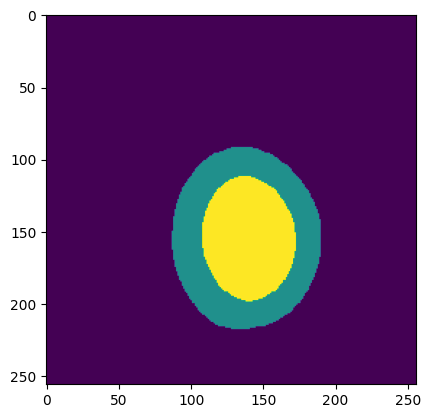

(array([0, 1, 2], dtype=uint8), array([55221,  5944,  4371]))


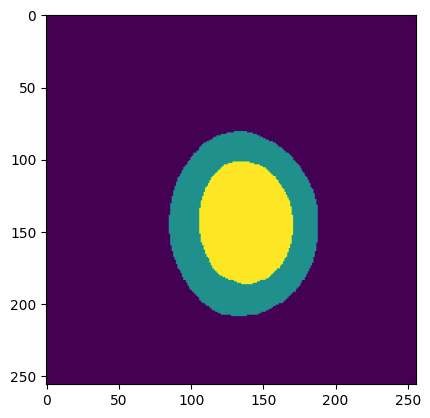

(array([0, 1, 2], dtype=uint8), array([55327,  5822,  4387]))


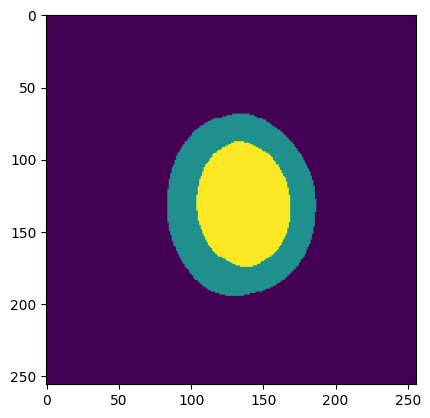

(array([0, 1, 2], dtype=uint8), array([55331,  5839,  4366]))


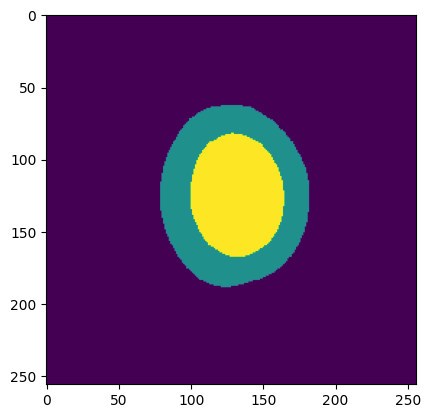

(array([0, 1, 2], dtype=uint8), array([55331,  5881,  4324]))


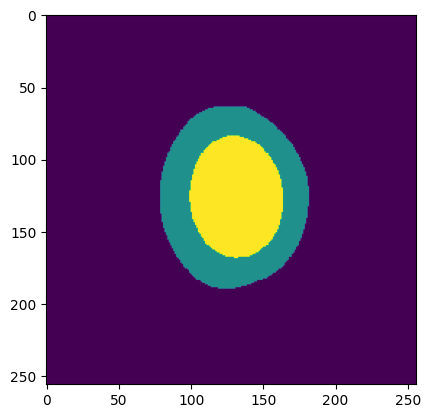

(array([0, 1, 2], dtype=uint8), array([55449,  5797,  4290]))


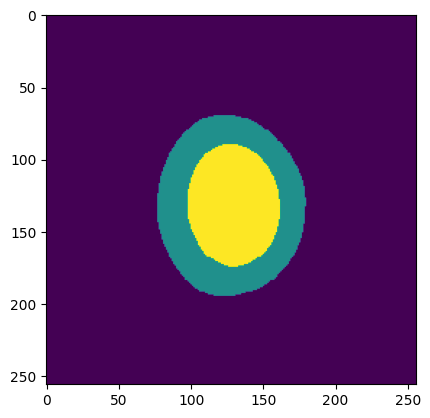

(array([0, 1, 2], dtype=uint8), array([55692,  5660,  4184]))


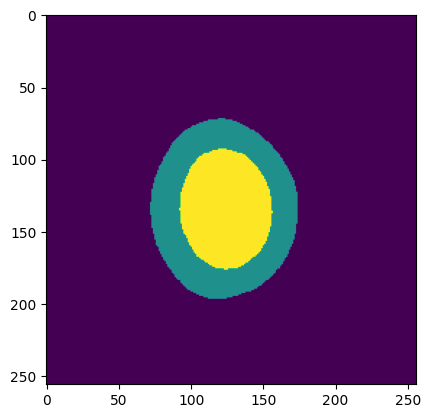

(array([0, 1, 2], dtype=uint8), array([55848,  5550,  4138]))


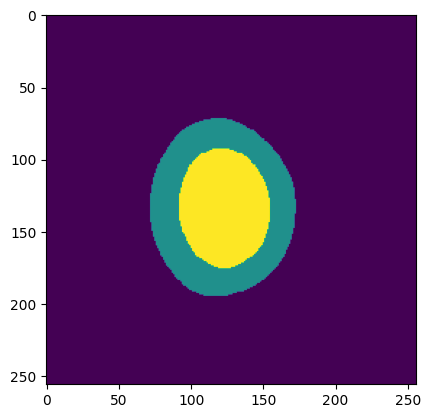

(array([0, 1, 2], dtype=uint8), array([55839,  5530,  4167]))


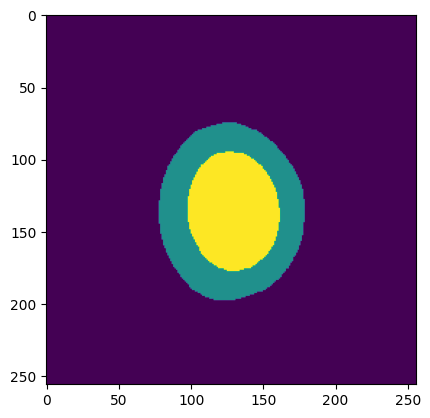

(array([0, 1, 2], dtype=uint8), array([55714,  5622,  4200]))


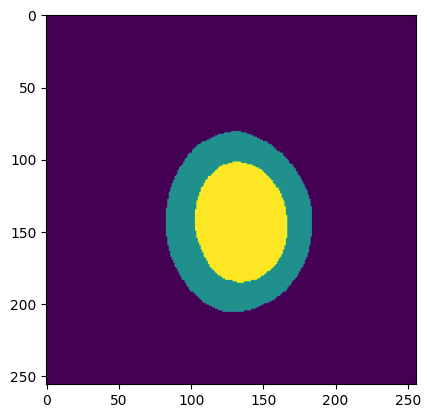

In [132]:
for i in range(img_video1.shape[0]):
    plt.imshow(masks[i])
    print(np.unique(masks[i], return_counts=1))
    plt.show()

datasets/Cataract-1K/masks_real/case_2286/0000000697.png


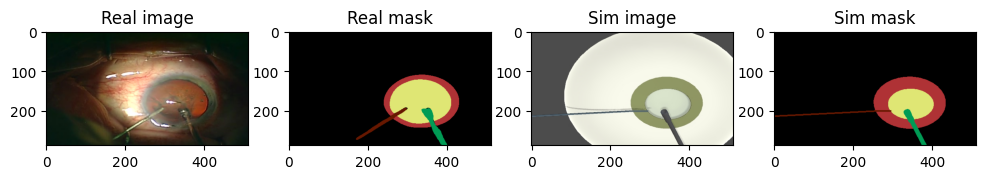

datasets/Cataract-1K/masks_real/case_2286/0000000023.png


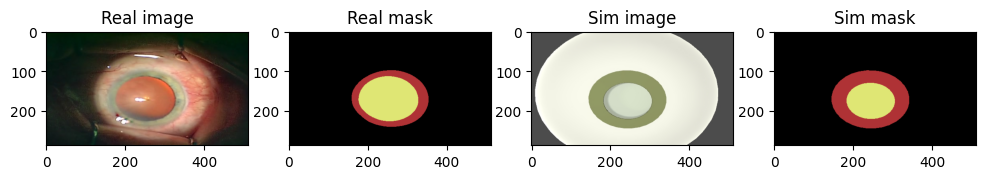

datasets/Cataract-1K/masks_real/case_2286/0000000487.png


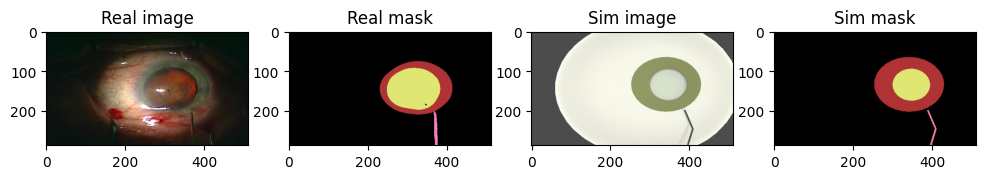

datasets/Cataract-1K/masks_real/case_2286/0000000867.png


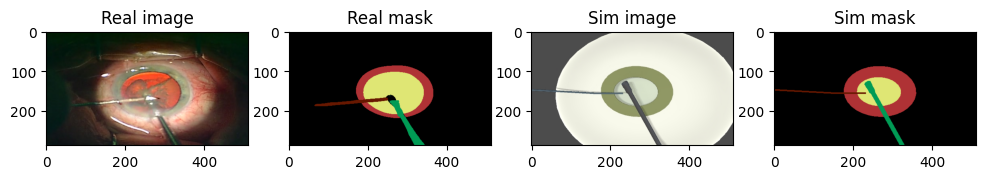

datasets/Cataract-1K/masks_real/case_2286/0000000292.png


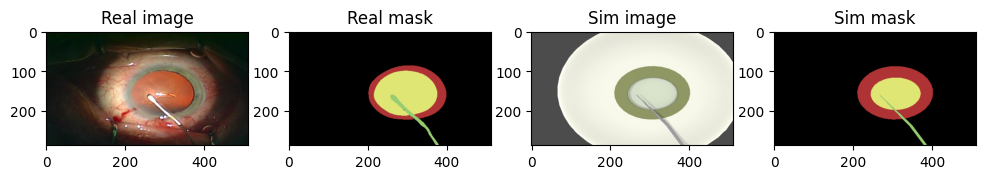

In [31]:
# base_folder = "datasets/Cataract-1K/video_frames_jpg"
base_folder = "datasets/Cataract-1K/masks_real"


base_dir = Path(base_folder)
all_cases_data = []

# Common image extensions (adjust if your masks use a different format)
valid_extensions = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}

# 1) Iterate over subfolders
for i,case_folder in enumerate(base_dir.glob("case_*")):
    if not case_folder.is_dir():
        continue
        

    if i == 1:
        break
    case_name = case_folder.name
    
    # Gather all image paths in the current subfolder
    image_paths = [
        p for p in case_folder.iterdir() 
        if p.is_file() and p.suffix.lower() in valid_extensions
    ]
    
    num_images = len(image_paths)
    if num_images == 0:
        print(f"Warning: No images found in {case_name}. Skipping.")
        continue

    case_class_counts = {}
    total_pixels = 0

    # Iterate over images in the subfolder
    for img_path in image_paths[:5]:
        print(img_path)
        # Read image unchanged to preserve exact mask/pixel values
        mask_real = Image.open(img_path)

        img_path2 = str(img_path)
        img_path_real = img_path2.replace("masks_real", "video_frames_jpg", 1)
        img_path_real = img_path_real.replace("png", "jpg")

        img_real = Image.open(img_path_real)



        maskpath = str(img_path2)
        maskpath = maskpath.replace("masks_real", "video_frames_sim", 1)
        maskpath = maskpath.replace("png", "jpg")
        img_sim = Image.open(maskpath)

        maskpath = str(img_path2)
        maskpath = maskpath.replace("masks_real", "masks_sim", 1)
        maskpath = maskpath.replace("jpg", "png")
        mask_sim = Image.open(maskpath)




        plt.figure(figsize=(12,4))
        plt.subplot(141)

        plt.title("Real image")
        plt.imshow(img_real)


        plt.subplot(142)
        plt.title("Real mask")
        plt.imshow(mask_real)

        plt.subplot(143)
        plt.title("Sim image")
        plt.imshow(img_sim)

        plt.subplot(144)
        plt.title("Sim mask")
        plt.imshow(mask_sim)

        plt.show()

# target_path = "datasets/Cataract-1K/video_frames_jpg/case_2005/0000000001.jpg"

# mask = Image.open(target_path)



# mask = np.asarray(mask)
# print(mask.shape)
# # print(np.unique(mask, return_counts=1))

# plt.imshow(mask)
            

In [24]:
c =0
for x in base_dir.glob("case_*"):
    c = c+1

c

1068

In [ ]:
# Check if masks from masks_sim and masks_real are the same



case_name  case_2286
datasets/Cataract-1K/video_frames_jpg/case_2286/0000000977.jpg
datasets/Cataract-1K/masks_sim/case_2286/0000000977.png


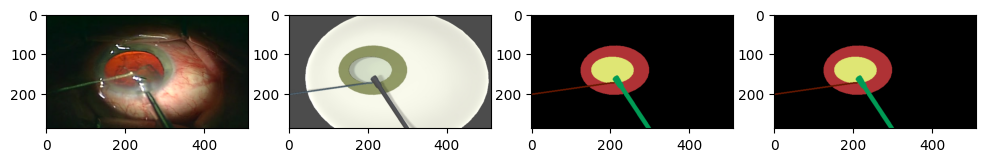

datasets/Cataract-1K/video_frames_jpg/case_2286/0000000282.jpg
datasets/Cataract-1K/masks_sim/case_2286/0000000282.png


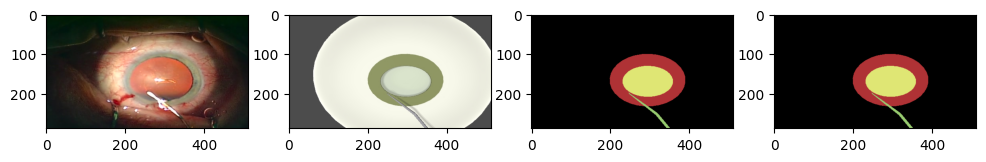

datasets/Cataract-1K/video_frames_jpg/case_2286/0000000698.jpg
datasets/Cataract-1K/masks_sim/case_2286/0000000698.png


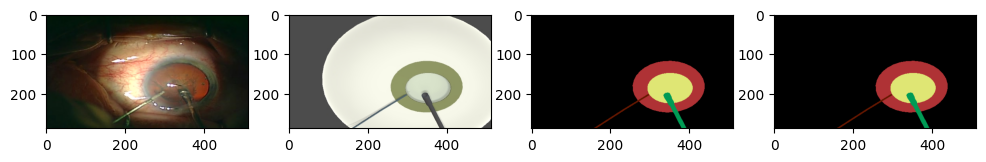

datasets/Cataract-1K/video_frames_jpg/case_2286/0000000710.jpg
datasets/Cataract-1K/masks_sim/case_2286/0000000710.png


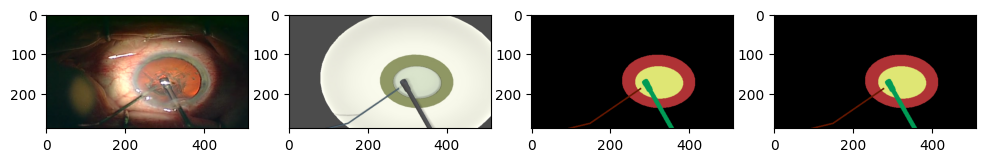

datasets/Cataract-1K/video_frames_jpg/case_2286/0000000878.jpg
datasets/Cataract-1K/masks_sim/case_2286/0000000878.png


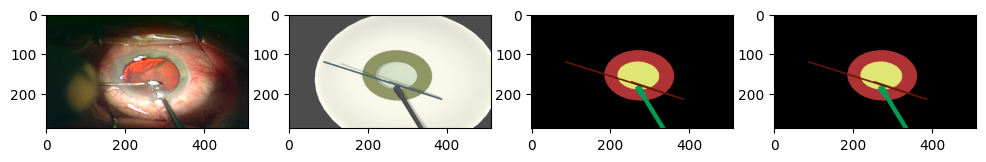

case_name  case_2905
datasets/Cataract-1K/video_frames_jpg/case_2905/0000001127.jpg


FileNotFoundError: [Errno 2] No such file or directory: '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_sim/case_2905/0000001127.jpg'

In [13]:
base_folder = "datasets/Cataract-1K/video_frames_jpg"

base_dir = Path(base_folder)
all_cases_data = []

# Common image extensions (adjust if your masks use a different format)
valid_extensions = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}

# 1) Iterate over subfolders
for i,case_folder in enumerate(base_dir.glob("case_*")):
    if not case_folder.is_dir():
        continue
        

    if i == 5:
        break
    case_name = case_folder.name
    print("case_name ", case_name)
    
    # Gather all image paths in the current subfolder
    image_paths = [
        p for p in case_folder.iterdir() 
        if p.is_file() and p.suffix.lower() in valid_extensions
    ]
    
    num_images = len(image_paths)
    if num_images == 0:
        print(f"Warning: No images found in {case_name}. Skipping.")
        continue

    case_class_counts = {}
    total_pixels = 0

    # Iterate over images in the subfolder
    for img_path in image_paths[:5]:
        print(img_path)
        # Read image unchanged to preserve exact mask/pixel values
        img = Image.open(img_path)

        img_path2 = str(img_path)
        img_path2 = img_path2.replace("jpg", "sim", 1)
        mask = Image.open(img_path2)



        maskpath = str(img_path2)
        maskpath = maskpath.replace("video_frames_sim", "masks_sim", 1)
        maskpath = maskpath.replace("jpg", "png")
        mask2 = Image.open(maskpath)


        maskpath = maskpath.replace("video_frames_sim", "masks_sim", 1)
        maskpath = maskpath.replace("jpg", "png")
        mask3 = Image.open(maskpath)

        print(maskpath)



        plt.figure(figsize=(12,4))
        plt.subplot(141)

        plt.imshow(img)


        plt.subplot(142)
        plt.imshow(mask)

        plt.subplot(143)
        plt.imshow(mask2)

        plt.subplot(144)
        plt.imshow(mask3)

        plt.show()


In [ ]:
0000001127
0000001127

In [17]:
p = '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2905/0000001127.jpg'

In [18]:
img = Image.open(p)


In [2]:
import os
from torch.utils.data import Dataset
import cv2
import PIL
from PIL import Image
import pickle
import numpy as np
import torch
import random
import pandas as pd



class DatasetRetinaVideo_v2(Dataset):
    def __init__(self, image_size = 256, from_file = [], num_frames = 1):
        self.data = []
        # with open("/home/MichalMo/projects/SurGrID/datasets/Cataract-1K/Cataract_1K_seg_full.json", 'rt') as f:
        #     for line in f:
        #         self.data.append(json.loads(line))



        # self.df = pd.read_csv("/home/MichalMo/projects/SurGrID/datasets/Cataract-1K/GFG_test.csv")
        # print(self.df.columns)
        # print(self.df.head(3))

        self.image_shape = (image_size, image_size)

        if len(from_file) > 0:


            with open(from_file, "rb") as f:
                self.image_paths = pickle.load(f)


        # self.image_paths = self.image_paths[:10]
        print(f"Loaded {len(self.image_paths)} samples")


    def __len__(self):
        return len(self.image_paths) 


    def load_image(self, path, img_type):

        if img_type == "image":

            image = Image.open(path)

            image = np.asarray(image)
            image = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)

            image = image.astype(np.float16).transpose(2,0,1)
            # image = image.astype(np.float16)
            # image = image.transpose(2,0,1)
            # image = np.moveaxis(image, -1, 0)
            image = image / 255.


        elif img_type == "mask":


            mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale


            mask = np.asarray(mask)
            mask = cv2.resize(mask, self.image_shape, interpolation=cv2.INTER_NEAREST)


            # segmentation = np.eye(14)[mask].astype(np.float32) #.transpose(2,0,1)

            # segmentation = segmentation.astype(np.float16)


            # # print(image.shape, segmentation.shape)
            # segmentation = segmentation.transpose(2,0,1)

            image = mask

        return image


    def get_batch(self, paths):

        # base_idx = idx % len(self.df)
        image_list = []
        mask_list = []

        images_paths = paths[:len(paths)//2]
        masks_paths = paths[len(paths)//2:]

        # print(len(images_paths), len(masks_paths))
        # print(images_paths[0], masks_paths[0])
        # print(images_paths[:5])

        # print(masks_paths[:5])

        for path in images_paths:


            image = self.load_image(path, img_type ="image")

            image_list.append(image)


        for path in masks_paths:


            mask = self.load_image(path, img_type = "mask")

            mask_list.append(mask)

        images = np.stack(image_list)
        masks = np.stack(mask_list)

        return images, masks



    def __getitem__(self, idx):
        idxs = self.image_paths[idx]
        # print("idxs ", len(idxs))

        images, masks = self.get_batch(idxs)


        return dict(image=torch.tensor(images), mask=torch.tensor(masks), depth = "", video_name="")

In [35]:

class DatasetMultimodalVideo(Dataset):
    def __init__(self, image_size = 256,  main_path=None, record = None, num_frames = 21, limit_frames = None):
        self.data = []


        self.num_frames = num_frames
        self.record = record
        self.main_path = main_path
        case_list = sorted(os.listdir(os.path.join(self.main_path, record)))
        self.image_numbers = [x[-8:-4] for x in case_list]

        if limit_frames:
            assert (limit_frames >= num_frames)
            self.image_numbers = self.image_numbers[:limit_frames]

        self.image_shape = (image_size, image_size)
        # print(len(self.image_numbers))
        # print(self.image_numbers)

        print(f"Loaded {len(self.image_numbers)} samples")


    def __len__(self):
        return len(self.image_numbers) 



    def load_image(self, num, img_type):

        assert img_type in ["image", "mask", "depth"]



        if img_type == "image":
            path = os.path.join(self.main_path, self.record, f"frame_{num}.png")

        elif img_type == "mask":
            path = os.path.join(self.main_path, self.record+ "_final", f"mask_{num}.png")

        elif img_type =="depth":
            path = os.path.join(self.main_path, self.record+ "_depth_synth", f"depth_{num}.png")


        image = Image.open(path)

        image = np.asarray(image)

        if img_type == "image":

            image = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)
            image = np.moveaxis(image, -1, 0)
            image = image / 255.

        elif img_type == "depth":
            image = np.moveaxis(image, -1, 0)

        elif img_type == "mask":
            image = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)

        return image



    def get_batch(self, indexes):

        # base_idx = idx % len(self.df)
        image_list = []
        mask_list = []
        depth_list = []


        for idx in indexes:
            num = self.image_numbers[idx]

            # print(num)

            image = self.load_image(num, "image")
            mask = self.load_image(num, "mask")
            depth = self.load_image(num, "depth")

            image_list.append(image)
            mask_list.append(mask)
            depth_list.append(depth)
        

        images = np.stack(image_list)
        masks = np.stack(mask_list)
        depths = np.stack(depth_list)

        return images, masks, depths


    def __getitem__(self, idx):


        max_start = len(self.image_numbers) - self.num_frames

        # one random iteration
        start_idx = random.randint(0, max_start)
        batch_indexes = range(start_idx, start_idx + self.num_frames)
        # print(batch_indexes)


        images, masks, depths = self.get_batch(batch_indexes)

        # print(images.shape, masks.shape, depths.shape)
        video_name = f"video_{self.record}_{start_idx}_{start_idx + self.num_frames}"




        # print("prompt", prompt, type(prompt)) # depth = torch.tensor(depth)
        return dict(image=torch.tensor(images), mask=torch.tensor(masks), depth = torch.tensor(depths), video_name =video_name)




In [36]:
test_dataset = DatasetMultimodalVideo(image_size=256,
                            main_path=f'/home/MichalMo/projects/ControlNet-diffusers/records_cadis_1/records_single_files',
                            record = "r2", num_frames= 21, limit_frames = None)


Loaded 134 samples


In [38]:
for step, batch in enumerate(test_dataset):

    print(batch.keys())
    image = batch["image"]
    print(image.shape, torch.min(image), torch.max(image))
    print(batch["mask"].shape, np.unique(batch["mask"], return_counts=1))


    # d = segmentation = F.one_hot(batch["mask"], num_classes=10)
    # print(d.shape)
    print(batch["depth"].shape)
    print(batch["video_name"])


    if step ==0:
        break
    


dict_keys(['image', 'mask', 'depth', 'video_name'])
torch.Size([21, 3, 256, 256]) tensor(0., dtype=torch.float64) tensor(0.9882, dtype=torch.float64)
torch.Size([21, 256, 256]) (array([0, 1, 2, 3, 5, 6, 8], dtype=uint8), array([122502, 541291, 459152, 172242,  53421,  21604,   6044]))
torch.Size([21, 3, 256, 256])
video_r2_75_96


In [4]:
import os, math, random
import json
import glob
import cv2
from natsort import natsorted
from PIL import Image
import numpy as np
from decord import VideoReader

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as FF
from torch.utils.data.dataset import Dataset
import torchvision.transforms as transforms
from diffusers.utils import logging
import albumentations as A
import networkx as nx
from torch_geometric.utils import from_networkx
from torch_geometric.data import Batch


class SurgicalDataset_my(Dataset):
    def __init__(
            self,
            video_folder,
            split_mode,
            dataset_name,
            class_size=None,
            ignore_index=None,
            sample_size=256, 
            sample_n_frames=16,
            overlap_size=1,
            frame_stride=2,
            apply_augmentation=False,
            train_graph_encoder=False,
            return_graph_emb=False,
            **kwargs,
        ):
        self.split_mode = split_mode
        self.dataset_name = dataset_name
        self.class_size = class_size
        self.ignore_index = ignore_index
        self.sample_n_frames = sample_n_frames
        self.apply_augmentation = apply_augmentation
        self.train_graph_encoder = train_graph_encoder
        self.return_graph_emb = return_graph_emb
        sample_size = tuple(sample_size) if not isinstance(sample_size, int) else (sample_size, sample_size)
        
        # separate transform bcs pixel_transform can transform multiple frames together.
        # graph transform with albumentation for easier mask handling
        self.pixel_rescale = transforms.Compose([
                                transforms.Resize(sample_size, antialias=None),
                                transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True)])

        self.pixel_rescale = transforms.Compose([
                                transforms.Resize(sample_size, antialias=None)])


        self.graph_rescale = A.Resize(sample_size[0], sample_size[1], interpolation=cv2.INTER_LANCZOS4)

        if self.apply_augmentation:
            additional_augment_targets = {}
            for i in range(1, self.sample_n_frames + 1):
                additional_augment_targets[f"image{i}"] = "image"
                additional_augment_targets[f"mask{i}"] = "mask"
                additional_augment_targets[f"cond{i}"] = "image"
            additional_augment_targets[f"cond"] = "image"

            #TODO: Think about adding cropping augmentations as well. Think throughly if would be problematic or not
            self.augment_trans = A.Compose([A.Resize(256, 256, interpolation=cv2.INTER_LANCZOS4),
                                            A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0),
                                            A.HorizontalFlip(p=0.20),
                                            A.VerticalFlip(p=0.50),
                                            A.RandomRotate90(p=0.10)],
                                            additional_targets=additional_augment_targets)
            
        video_txt = [os.path.join(vid_folder, "splits", split_mode+".txt") for vid_folder in video_folder]

        self.video_list = []
        for txt in video_txt:
            with open(txt, "r") as f:
                self.video_list.extend([os.path.join(os.path.dirname(os.path.dirname(txt)), "video_frames_jpg", x) for x in f.read().splitlines()])

        if self.dataset_name == "cataract":
            text = "sequence during cataract surgery."
        elif self.dataset_name == "cholec":
            text = "sequence during cholecystectomy surgery."

        else:
            raise NotImplementedError
        
        self.text = text
        self.sample = []
        for video in self.video_list:
            # print(video)
            frame_path = video
            segm_path = video.replace("video_frames_jpg", "masks_sim")
            graph_path = video.replace("video_frames_jpg", "scene_graphs_sim")
            cond_video_path = video.replace("video_frames_jpg", "video_frames_sim")

            frame_list = natsorted(glob.glob(frame_path + "/*.jpg"))[::frame_stride]
            frame_list = [os.path.basename(x) for x in frame_list]
            segm_list = natsorted(glob.glob(segm_path + "/*.png"))[::frame_stride]
            graph_list = natsorted(glob.glob(graph_path + "/*.pt"))[::frame_stride]
            cond_video_list = natsorted(glob.glob(cond_video_path + "/*.jpg"))[::frame_stride]


            # print(frame_path, segm_path, graph_path, cond_video_path)
            
            
            for n in range(0, len(frame_list), overlap_size):
                if n + self.sample_n_frames + 1 < len(frame_list):
                    self.sample.append({"video": os.path.basename(video),
                                        "video_folder": os.path.dirname(os.path.dirname(video)),
                                        "frame": frame_list[n:n + self.sample_n_frames + 1], # Adding one for optical flow info for graph construction under augmentation
                                        "segm": segm_list[n:n + self.sample_n_frames + 1], 
                                        "graph": graph_list[n:n + self.sample_n_frames],
                                        "cond_video": cond_video_list[n:n + self.sample_n_frames + 1]}) 

        if self.return_graph_emb:
            self.validation_graphs_loaded = []
            if 'validation_graphs' in kwargs:
                for graph in kwargs['validation_graphs']: 
                    # doing this bcs dont wanna list all 16 graphs in config file
                    all_graph = natsorted(glob.glob(os.path.dirname(graph) + "/*"))
                    index = all_graph.index(graph)
                    graphs = all_graph[index:index+self.sample_n_frames]
                    graphs = [torch.load(i) for i in graphs]
                    graphs = Batch.from_data_list(graphs)
                    self.validation_graphs_loaded.append(graphs)

        self.validation_seq_paths = []
        if 'validation_first_frames' in kwargs:
            for frame in kwargs['validation_first_frames']:
                all_frame = natsorted(glob.glob(os.path.dirname(frame) + "/*"))
                index = all_frame.index(frame)
                frames = all_frame[index:index+self.sample_n_frames]
                self.validation_seq_paths.append(frames)

        self.validation_cond_seq_paths = []
        if 'validation_cond_videos' in kwargs:
            for frame in kwargs['validation_cond_videos']:
                all_frame = natsorted(glob.glob(os.path.dirname(frame) + "/*"))
                index = all_frame.index(frame)
                frames = all_frame[index:index+self.sample_n_frames]
                self.validation_cond_seq_paths.append(frames)

    def load_scene_graph(self, graph_path):
        graph = torch.load(graph_path)
        if "x" not in graph:
            # dummy graph for the case where the graph is empty 
            G = nx.Graph()
            features = [0.0] * (self.class_size + 6)
            if self.ignore_index in ["first", "last"]:
                features[self.class_size - 1 if self.ignore_index == "last" else 0] = 1
            G.add_node(len(G.nodes), features=features, centroid=(0.0, 0.0))
            G.add_node(len(G.nodes), features=features, centroid=(0.0, 0.0))

            for idx1, data1 in G.nodes(data=True):
                for idx2, data2 in G.nodes(data=True):
                    if idx1 >= idx2:
                        continue
                    G.add_edge(idx1, idx2)
                data1['x'] = data1['features']
            graph = from_networkx(G)
        return graph

    def __len__(self):
        return len(self.sample)

    def __getitem__(self, index):
        items = {}
        frames = []
        graphs = []
        segmentations = []
        cond_videos = []
        class_labels = []
        sequence = self.sample[index]

        if self.train_graph_encoder or self.return_graph_emb:
            if not self.apply_augmentation:
                for idx in range(self.sample_n_frames):
                    graph = self.load_scene_graph(sequence["graph"][idx])
                    graphs.append(graph)
                graphs = Batch.from_data_list(graphs)
                # items["graph"] = graphs
        
            # Images and masks to pass to the graphconstructor to form graph on the fly if aumentation is applied
            else:
                graph_images = []
                graph_segmentations = []
                graph_conds = []

        # Temporary until augmentation is applied
        temp_frames = []
        temp_segmentations = []
        temp_cond_videos = []

        # Adding one for optical flow info for graph construction under augmentation
        for idx in range(self.sample_n_frames + 1):
            image = os.path.join(sequence["video_folder"], "video_frames_jpg", sequence["video"], sequence["frame"][idx])
            image = np.array(Image.open(image).convert("RGB"))
            segmentation = np.array(Image.open(sequence['segm'][idx]))
            cond_frame = np.array(Image.open(sequence['cond_video'][idx]).convert("RGB"))
            
            temp_frames.append(image)
            temp_segmentations.append(segmentation)
            temp_cond_videos.append(cond_frame)

        # Splliting this processing so that same augmentation can be applied on entire sequence instead.
        if self.apply_augmentation:
            kwargs = {"image": temp_frames[0], "mask": temp_segmentations[0], "cond": temp_cond_videos[0]}
            for idx in range(1, self.sample_n_frames + 1):
                kwargs[f"image{idx}"] = temp_frames[idx]
                kwargs[f"mask{idx}"] = temp_segmentations[idx]
                kwargs[f"cond{idx}"] = temp_cond_videos[idx]

            result = self.augment_trans(**kwargs)
            temp_frames = [result["image"]] + [result[f"image{i}"] for i in range(1, self.sample_n_frames + 1)]
            temp_segmentations = [result["mask"]] + [result[f"mask{i}"] for i in range(1, self.sample_n_frames + 1)]
            temp_cond_videos = [result["cond"]] + [result[f"cond{i}"] for i in range(1, self.sample_n_frames + 1)]

            #TODO: Using to_tensor and torch.from numpy below looks ugly but needed. Check more elegent way
            if self.train_graph_encoder or self.return_graph_emb:
                for frm, seg, cnd in zip(temp_frames, temp_segmentations, temp_cond_videos):
                    graph_images.append(FF.to_tensor(frm)) 
                    graph_segmentations.append(torch.from_numpy(seg))
                    graph_conds.append(FF.to_tensor(cnd))
                    # items["graph_image"] = torch.stack(graph_images)
                    # items["graph_segmentation"] = torch.stack(graph_segmentations)
                    # items["graph_cond"] = torch.stack(graph_conds)

        # For now handling dataset of diffusion and graph encoder separately for simplicity
        if self.train_graph_encoder:
            for idx in range(self.sample_n_frames): 
                image, segmentation = self.graph_rescale(image=temp_frames[idx], mask=temp_segmentations[idx]).values()
                image = (image / 127.5 - 1.0).astype(np.float32)
                image = torch.from_numpy(image).permute(2, 0, 1)
                frames.append(image)

                segmentation = torch.from_numpy(segmentation.astype(np.int64))

                class_label = torch.zeros(self.class_size, dtype=torch.int64)
                class_label[segmentation.unique().long()] = 1
                class_labels.append(class_label)

                # print(segmentation.shape)
                
                # segmentation = F.one_hot(segmentation, num_classes=self.class_size)
                segmentation = segmentation.to(dtype=torch.float32)
                segmentations.append(segmentation)

            items["image"] = torch.stack(frames)
            items["class_label"] = torch.max(torch.stack(class_labels), dim=0).values
            items["mask"] = torch.stack(segmentations)
            items["all_frame_path"] = [os.path.join(sequence["video_folder"], "video_frames_jpg", sequence["video"], sequence["frame"][i]) for i in range(self.sample_n_frames)]
            items["first_frame_path"] = os.path.join(sequence["video_folder"], "video_frames_jpg", sequence["video"], sequence["frame"][0])
            # items["text"] = self.text


        else:
            for idx in range(self.sample_n_frames):
                frames.append(temp_frames[idx])
                cond_videos.append(temp_cond_videos[idx])
                # print(type(temp_segmentations[idx]))
                # segmentation = torch.from_numpy(segmentation.astype(np.int64))
                _, segmentation = self.graph_rescale(image=temp_frames[idx], mask=temp_segmentations[idx]).values()

                segmentation = torch.from_numpy(segmentation).to(dtype=torch.float32)

                segmentations.append(segmentation)
            
            frames = np.array(frames)
            pixel_values = torch.from_numpy(frames).permute(0, 3, 1, 2).contiguous()
            pixel_values = (pixel_values / 255.0)
            # print("image", pixel_values.shape, torch.min(pixel_values), torch.max(pixel_values))

            pixel_values = self.pixel_rescale(pixel_values)
            # pixel_values = (pixel_values + 1.0) / 2.0

            cond_videos = np.array(cond_videos)
            cond_video_values = torch.from_numpy(cond_videos).permute(0, 3, 1, 2).contiguous()
            cond_video_values = cond_video_values / 255.0
            # cond_video_values = self.pixel_rescale(cond_video_values)


            # segmentations = np.array(segmentations)

            items["image"] = pixel_values
            items["cond_video_values"] = cond_video_values
            items["mask"] = torch.stack(segmentations)

            # items["text"] = self.text
            items["first_frame_path"] = os.path.join(sequence["video_folder"], "video_frames_jpg", sequence["video"], sequence["frame"][0])
            items["all_frame_path"] = [os.path.join(sequence["video_folder"], "video_frames_jpg", sequence["video"], sequence["frame"][i]) for i in range(self.sample_n_frames)]
            items["cond_video_path"] = [sequence["cond_video"][i] for i in range(self.sample_n_frames)]
        
            # print("before return ", items["first_frame_path"], items["all_frame_path"][0], items["cond_video_path"][0])
        return items

In [5]:
# from swomo.data.dataset import SurgicalDataset_my
# 

config = OmegaConf.load("configs/training/training_img_graph_vid_cataracts_test.yaml")

print(config.train_data)
train_dataset = SurgicalDataset_my(**config.train_data, train_graph_encoder = False)

{'dataset': 'surgical', 'dataset_name': 'cataract', 'video_folder': ['/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K'], 'class_size': 14, 'split_mode': 'train', 'return_graph_emb': False, 'return_cond_videos': True, 'sample_size': 256, 'sample_n_frames': 21, 'apply_augmentation': False, 'overlap_size': 100, 'frame_stride': 1, 'embedding_type': 'combined', 'model_masked': './checkpoints/Cataract-1K/graphencoder_masked/best_val_loss.pth', 'model_segclip': './checkpoints/Cataract-1K/graphencoder_segclip/best_val_loss.pth', 'graph_input_dim': 20, 'graph_hidden_dim': 256, 'graph_embedding_dim': 256, 'trainable': False, 'graph_conv_type': 'GATv2Conv', 'graph_norm_type': 'LayerNorm'}


In [15]:
b1 = train_dataset.__getitem__(16)
b1.keys()

dict_keys(['image', 'cond_video_values', 'mask', 'first_frame_path', 'all_frame_path', 'cond_video_path'])

In [16]:
b1["all_frame_path"]

['/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000001600.jpg',
 '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000001601.jpg',
 '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000001602.jpg',
 '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000001603.jpg',
 '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000001604.jpg',
 '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000001605.jpg',
 '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000001606.jpg',
 '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000001607.jpg',
 '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000001608.jpg',
 '/home/MichalMo/projects/SurgSora/SWoMo/datas

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


0
image torch.Size([21, 3, 256, 256]) tensor(-1.) tensor(1.)
torch.Size([21, 256, 256]) (array([0., 1., 2.], dtype=float32), array([1155975,  137760,   82521]))


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


1
image torch.Size([21, 3, 256, 256]) tensor(-1.) tensor(1.)
torch.Size([21, 256, 256]) (array([ 0.,  1.,  2.,  4., 12.], dtype=float32), array([1095861,  142866,   88650,   10387,   38492]))


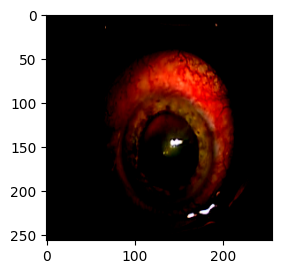

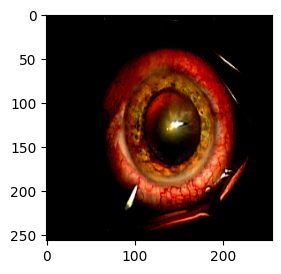

In [71]:
for step, batch in enumerate(train_dataset):

    # print(batch.keys())
    print(step)

    pixel_values = batch["image"]
    # pixel_values = rearrange(pixel_values, "b f c h w -> b f h w c")[0]

    print("image", pixel_values.shape, torch.min(pixel_values), torch.max(pixel_values))


    mask = batch["mask"]
    print(mask.shape, np.unique(mask, return_counts=1))


    plt.figure()
    plt.subplot(121)

    plt.imshow(np.array(pixel_values[0].permute(1,2,0)))




    if step ==1:
        break

In [19]:
len(train_dataset)

102

: 

In [8]:
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,

)


In [9]:
for step, batch in enumerate(train_dataloader):

    print(batch.keys())


    pixel_values = batch["image"]
    # pixel_values = rearrange(pixel_values, "b f c h w -> b f h w c")[0]

    print(pixel_values.shape)


    mask = batch["mask"]
    print(mask.shape, np.unique(mask, return_counts=1))


    if step ==0:
        break

dict_keys(['image', 'class_label', 'mask', 'all_frame_path', 'first_frame_path'])
torch.Size([1, 21, 3, 128, 128])
torch.Size([1, 21, 128, 128]) (array([0., 1., 2.], dtype=float32), array([288989,  34428,  20647]))
